In [11]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

In [ ]:
"""
Sobel Edge Detection
Smoothing (5 × 5 averaging)
Mask Creation: (Smooth)2
Sharpened: f + Mask
Gamma Correction
"""
def sobel(image):
    if len(image.shape) == 3: # Checks img height width and channels.
        image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY) # Then grayscales it.
    sobel_x = cv2.Sobel(image, cv2.CV_64F, 1,0, ksize=5)
    sobel_y = cv2.Sobel(image, cv2.CV_64F, 0,1, ksize=5)
    
    sobel_mag = np.sqrt(sobel_x**2 + sobel_y**2)
    sobel_mag = sobel_mag / sobel_mag.max()
    return sobel_mag

def smooth(image, kernel=5 , method = "average"):
    if method == "average":
        kernel_avg = np.ones((kernel,kernel),np.float64)/(kernel*kernel)
        return cv2.filter2D(image, -1, kernel_avg)  # Ig?
    
    if method =="gaussian":
        return cv2.GaussianBlur(image, (kernel,kernel),0)
    
    else:
        raise ValueError("Not supported")
    

def sharpen(image, m, strength=1.0):
    img = image.astype(np.float32) / 255.0

    if img.ndim == 3:
        m = m[..., np.newaxis]

    result = img + strength * m
    result = np.clip(result, 0, 1)

    return (result * 255).astype(np.uint8)

def gamma(image, gamma_value =0.7):
    img = image.astype(np.float32) / 255.0
    corrected = np.power(img, gamma_value)
    return (corrected * 255).astype(np.uint8)

"""
Laplacian
Smoothing (5 × 5 averaging)
Mask Creation: (Smooth)2
Sharpened: f + Mask
Logarthmic
"""
def laplacian(image):
    if len(image.shape) == 3: # Checks img height width and channels.
        image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY) # Then grayscales it.
    lap_kernel =  np.array([[0, -1, 0], [-1, 4, -1], [0, -1, 0]])
    lap = cv2.filter2D(image, -1, lap_kernel)
    return lap
    

def sharpen(image, m, strength=1.0):
    img = image.astype(np.float32) / 255.0

    if img.ndim == 3:
        m = m[..., np.newaxis]

    result = img + strength * m
    result = np.clip(result, 0, 1)

    return (result * 255).astype(np.uint8)

def log_transform(image):
    img = image.astype(np.float32) / 255.0
    
    # Apply log
    log_img = np.log1p(img)  # log(1 + r)
    
    # Normalize back to 0–1
    log_img = log_img / np.max(log_img)
    
    return (log_img * 255).astype(np.uint8)
    
""" 
Canny
Smoothing (5 × 5 averaging)
Mask Creation: (Smooth)2
Sharpened: f + Mask
Sigmoid
"""
def canny(image, low =100, high=200):
    if len(image.shape) == 3: # Checks img height width and channels.
        image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY) # Then grayscales it.
    edges = cv2.Canny(image, low, high)
    
    # Normalize
    edges = edges.astype(np.float32)/255.0
    return edges


def sigmoid(image, gain=10, cutoff=0.5):
    img = image.astype(np.float32) / 255.0

    sig = 1 / (1 + np.exp(-gain * (img - cutoff)))

    return (sig * 255).astype(np.uint8)





In [13]:
class SharpeningPipeline:
    def __init__(
        self,
        edge_method="sobel",
        smooth_method="average",
        final_transform="gamma",
        smooth_kernel=5,
        strength=1.0
    ):
        self.edge_method = edge_method
        self.smooth_method = smooth_method
        self.final_transform = final_transform
        self.smooth_kernel = smooth_kernel
        self.strength = strength
        
    def get_edges(self,image):
        if self.edge_method == "sobel":
            return sobel(image)
        
        elif self.edge_method =="laplacian":
            edges = laplacian(image).astype(np.float32)
            edges = np.abs(edges)
            if edges.max() != 0:
                edges = edges/edges.max()
            return edges
        
        elif self.edge_method == "canny":
            return canny(image)
        
        else:
            raise ValueError("ONLY 3 EDGE METHODS LEAVE ME ALONE.")
        
    def build_mask(self, image):
        edges = self.get_edges(image)

        smoothed = smooth(edges, kernel=self.smooth_kernel, method=self.smooth_method)

        m = smoothed ** 2

        max_val = m.max()
        if max_val != 0:
            m = m / max_val

        return m    
    
    def apply_transform(self, image):
        if self.final_transform == "gamma":
            return gamma(image, gamma_value=0.7)

        elif self.final_transform == "log":
            return log_transform(image)

        elif self.final_transform == "sigmoid":
            return sigmoid(image)

        else:
            return image
        
    def process(self, image):
        m = self.build_mask(image)
        sharp = sharpen(image, m, strength= self.strength)
        final = self.apply_transform(sharp)
        return final
    
    def compare(self, image_path):
        image = cv2.imread(image_path)
        if image is None:
            raise FileNotFoundError("Image not found")

        result = self.process(image)

        original_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        result_rgb = cv2.cvtColor(result, cv2.COLOR_BGR2RGB)

        plt.figure(figsize=(12, 5))

        plt.subplot(1, 2, 1)
        plt.imshow(original_rgb)
        plt.title("Original Image")
        plt.axis('off')

        plt.subplot(1, 2, 2)
        plt.imshow(result_rgb)
        plt.title(f"{self.edge_method} + {self.final_transform}")
        plt.axis('off')

        plt.show()

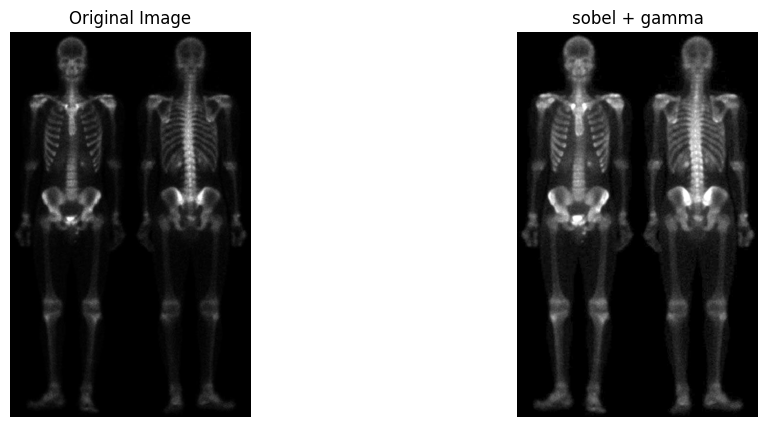

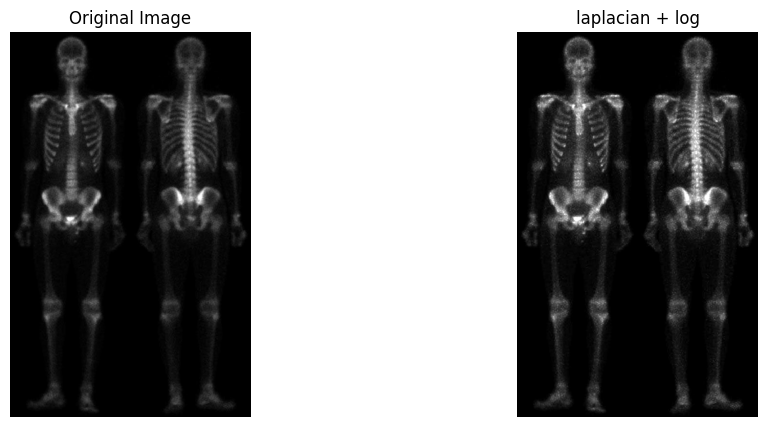

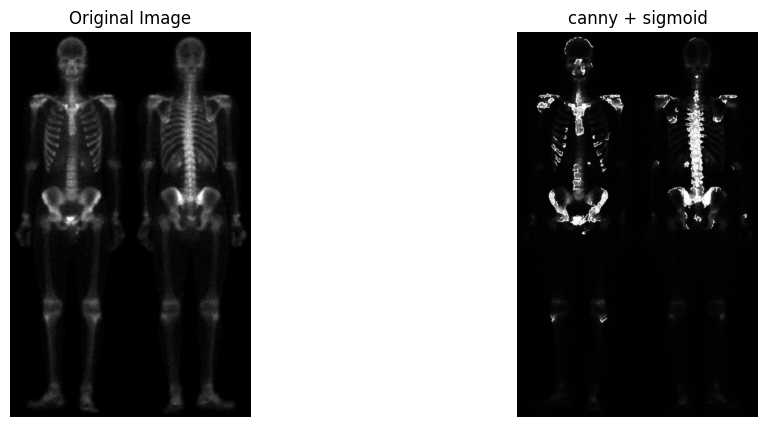

In [14]:
sobel_pipeline = SharpeningPipeline(
    edge_method="sobel",
    smooth_method="average",
    final_transform="gamma"
)

sobel_pipeline.compare("xray.png")

lap_pipeline = SharpeningPipeline(
    edge_method="laplacian",
    smooth_method="gaussian",
    final_transform="log"
)

lap_pipeline.compare("xray.png")

canny_pipeline = SharpeningPipeline(
    edge_method="canny",
    smooth_method="gaussian",
    final_transform="sigmoid"
)

canny_pipeline.compare("xray.png")

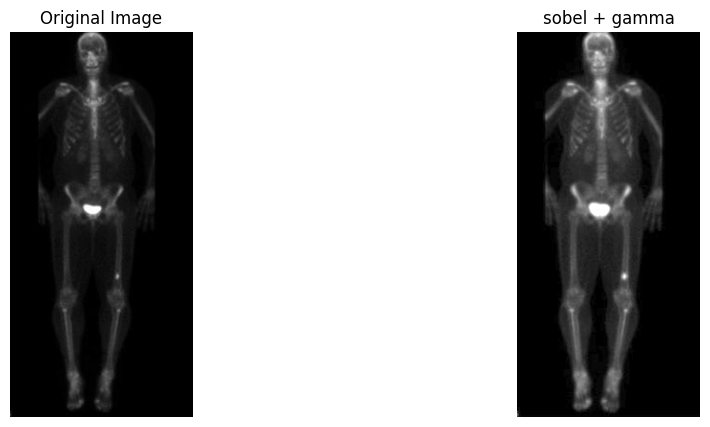

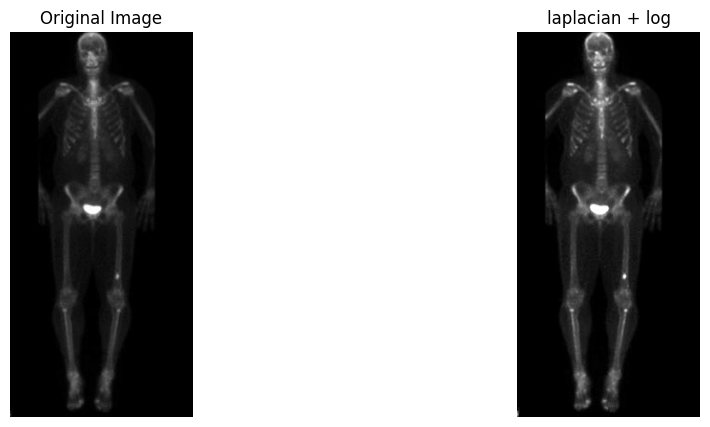

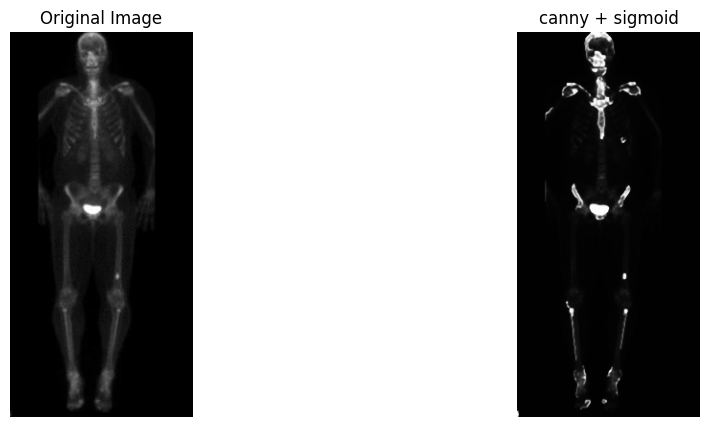

In [15]:
sobel_pipeline.compare("low_quality_xray.png")

lap_pipeline.compare("low_quality_xray.png")

canny_pipeline.compare("low_quality_xray.png")